In [2]:
from pathlib import Path
import sys

import numpy as onp
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.gridspec import GridSpec
from matplotlib.axes import Axes
_project_root = Path.cwd()
if _project_root.name == "notebooks":
  _project_root = _project_root.parent
if str(_project_root) not in sys.path:
  sys.path.insert(0, str(_project_root))

from examples.per_sym import (
  DomainConfig, _2π,  gaussian, bloch_wave, monatomic_dispersion,
  periodic_potential_from_sites,  nearest_neighbor_vectors, find_origin_site, 
	make_k_mesh, diatomic_dispersion
)
import src.symmetry as sym
from src.lattice_geometry import make_honeycomb_lattice, make_triangular_lattice
from plotting_utils import (
  PlotStyle, apply_matplotlib_style, _clean_axes, complex_to_rgb, save_path, subplots_list,
)

# Keep text as text in the SVG rather than converting everything to paths.
# mpl.rcParams["svg.fonttype"] = "none"
apply_matplotlib_style(PlotStyle(label_size=13, title_size=15, fig_title_size=18))


In [3]:
# ---- config
OUTDIR = Path("media/figures")
OUTDIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name, **kwargs):
  if name is None:
    return None
  return save_path(fig, OUTDIR / name, dpi=300, facecolor="white", **kwargs)

def clean_axes(ax):
  _clean_axes(ax, grid=True, hide_spines=("top", "right"))
  ax.spines["left"].set_linewidth(1.3)
  ax.spines["bottom"].set_linewidth(1.3)


In [4]:
# --- lattice + continuous grid
cfg = DomainConfig()
a = cfg.a

# --- discrete ring (periodic BCs): sites n = 0,...,N-1
x = onp.linspace(0, cfg.Lx, cfg.Nx, endpoint=False)
y = onp.linspace(0, cfg.Ly, cfg.Ny, endpoint=False)

X, Y = onp.meshgrid(x, y, indexing="xy")
grid = onp.stack((X, Y), axis=-1)
print(grid.shape)

# ---- energy splitting
E0 = 0.0
dE = 0.8
Emin = E0 - dE / 2
Emax = E0 + dE / 2
# ---- continuous spectrum
E_max = 8
E = onp.linspace(0, E_max, 400)


(800, 800, 2)


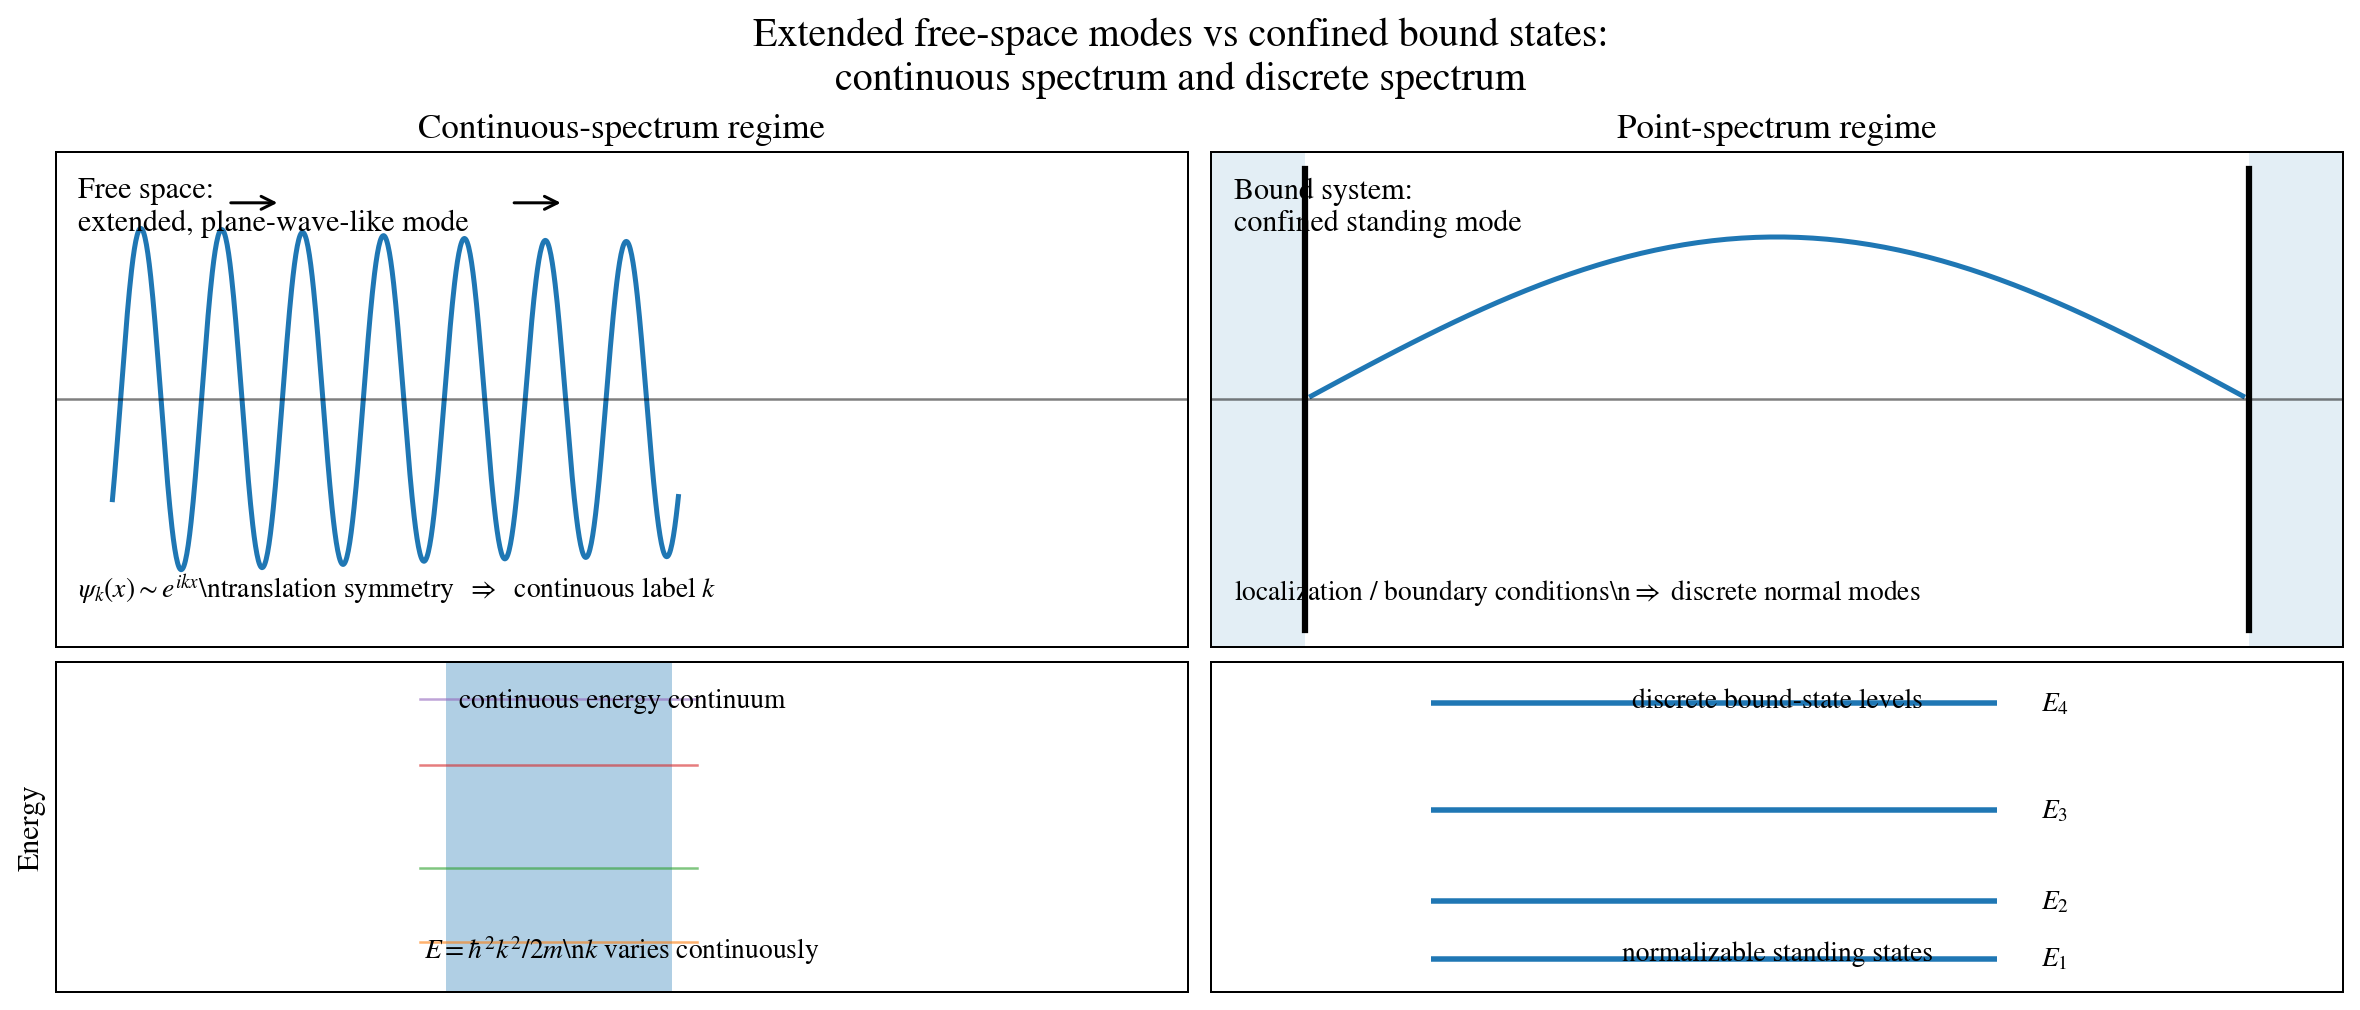

In [4]:

_x = 2 * x - 1
carrier = onp.cos(cfg.k0 * _x)

# Slight envelope only so the oscillation is visible on the slide;
# conceptually, this is meant to evoke an extended plane-wave-like state.
weak_env = 0.92 + 0.08 * gaussian(_x, sigma=7.0)
psi_free = weak_env * carrier

# ---- bound state in a confining well
Ω_xb = (-1.2, 1.2)
xb = onp.linspace(*Ω_xb, cfg.res_per_cell)

# Infinite-square-well-like standing wave inside [-1,1]
inside = onp.abs(xb) <= 1.0
psi_bound = onp.full_like(xb, onp.nan)
# One standing-wave mode
psi_bound[inside] = 0.95 * onp.sin(onp.pi * (xb[inside] + 1) / 2)



def make_free_vs_bound_spectrum_figure():

  ylim = (-1.45, 1.45)


  fig = plt.figure(figsize=(13, 5.5), constrained_layout=True)
  gs = fig.add_gridspec(2, 2, height_ratios=[3, 2])

  # Top row: wavefunctions / amplitudes
  ax_free = fig.add_subplot(gs[0, 0])
  ax_bound = fig.add_subplot(gs[0, 1])

  # Bottom row: spectra
  ax_free_spec = fig.add_subplot(gs[1, 0])
  ax_bound_spec = fig.add_subplot(gs[1, 1])

  # --------------------------
  # Left panel: free-space state
  # --------------------------
  ax_free.plot(x, psi_free, lw=2)
  ax_free.axhline(0, lw=1, color='black', alpha=0.5)

  # Add subtle arrows to suggest translational freedom
  for x0 in [-8, -3, 2, 7]:
    ax_free.annotate(
      "",
      xy=(x0 + 1.0, 1.15),
      xytext=(x0, 1.15),
      arrowprops=dict(arrowstyle="->", lw=1.2)
    )

  lbl = "Free space:\nextended, plane-wave-like mode"
  ax_free.text(0.02, 0.95, lbl, transform=ax_free.transAxes, ha="left", va="top", fontsize=12)
  lbl = r"$\psi_k(x)\sim e^{ikx}$\ntranslation symmetry  $\Rightarrow$  continuous label $k$"
  ax_free.text(0.02, 0.08, lbl, transform=ax_free.transAxes, ha="left", va="bottom", fontsize=11)
  ax_free.set(xlim=(_x.min(), _x.max()), ylim=ylim, xticks=[], yticks=[],
              title="Continuous-spectrum regime")
  ax_free.title.set_fontsize(14)

  # --------------------------
  # Right panel: bound state in a confining well
  # --------------------------

  # Draw confining walls
  ax_bound.plot([-1, -1], [-1.35, 1.35], lw=2.5, color='black')
  ax_bound.plot([1, 1], [-1.35, 1.35], lw=2.5, color='black')
  ax_bound.plot(xb, psi_bound, lw=2)

  # Light shading for forbidden/outside region
  ax_bound.axvspan(Ω_xb[0], -1.0, alpha=0.12)
  ax_bound.axvspan(1.0, Ω_xb[1], alpha=0.12)
  ax_bound.axhline(0, lw=1, color='black', alpha=0.5)

  lbl = "Bound system:\nconfined standing mode"
  ax_bound.text(0.02, 0.95, lbl, transform=ax_bound.transAxes, ha="left", va="top", fontsize=12)
  lbl = r"localization / boundary conditions\n$\Rightarrow$ discrete normal modes"
  ax_bound.text(0.02, 0.08, lbl, transform=ax_bound.transAxes, ha="left", va="bottom", fontsize=11)

  ax_bound.set(xlim=Ω_xb, ylim=ylim, xticks=[], yticks=[],
               title="Point-spectrum regime")
  ax_bound.title.set_fontsize(14)

  # --------------------------
  # Bottom-left: continuous spectrum
  # --------------------------
  ax_free_spec.plot(onp.zeros_like(E), E, alpha=0)  # set axes scale cleanly

  # Thick vertical "continuum" bar
  ax_free_spec.fill_betweenx(E, -0.18, 0.18, alpha=0.35)

  # A few labels to suggest continuous energy values
  for Ei in [1.2, 3.0, 5.5, 7.1]:
    ax_free_spec.plot([-0.22, 0.22], [Ei, Ei], lw=1.0, alpha=0.6)

  Elim = (E.min(), E.max())
  lbl = "continuous energy continuum"
  ax_free_spec.text(0.5, 0.92, lbl, transform=ax_free_spec.transAxes, ha="center", va="top", fontsize=11)
  lbl = r"$E=\hbar^2 k^2 / 2m$\n$k$ varies continuously"
  ax_free_spec.text(0.5, 0.08, lbl, transform=ax_free_spec.transAxes, ha="center", va="bottom", fontsize=11)
  ax_free_spec.set(xlim=(-0.8, 1.0), ylim=Elim, xticks=[], yticks=[], ylabel="Energy")
  ax_free_spec.yaxis.label.set_size(12)

  # --------------------------
  # Bottom-right: discrete spectrum
  # --------------------------
  discrete_levels = [0.8, 2.2, 4.4, 7.0]
  for n, En in enumerate(discrete_levels, start=1):
    ax_bound_spec.hlines(En, -0.45, 0.45, lw=2.2)
    ax_bound_spec.text(0.52, En, rf"$E_{n}$", va="center", fontsize=11)

  ax_bound_spec.text(0.5, 0.92,
    "discrete bound-state levels",
    transform=ax_bound_spec.transAxes, ha="center", va="top", fontsize=11)
  ax_bound_spec.text(0.5, 0.08,
    "normalizable standing states",
    transform=ax_bound_spec.transAxes, ha="center", va="bottom", fontsize=11)
  ax_bound_spec.set(xlim=(-0.8, 1.0), ylim=Elim, xticks=[], yticks=[])


  fig.suptitle(
    "Extended free-space modes vs confined bound states:\n"
    "continuous spectrum and discrete spectrum",
    fontsize=16
  )
  return fig


if __name__ == "__main__":
  fig = make_free_vs_bound_spectrum_figure()
  # savefig(fig, "free_vs_bound_spectrum.png", bbox_inches="tight")
  plt.show()

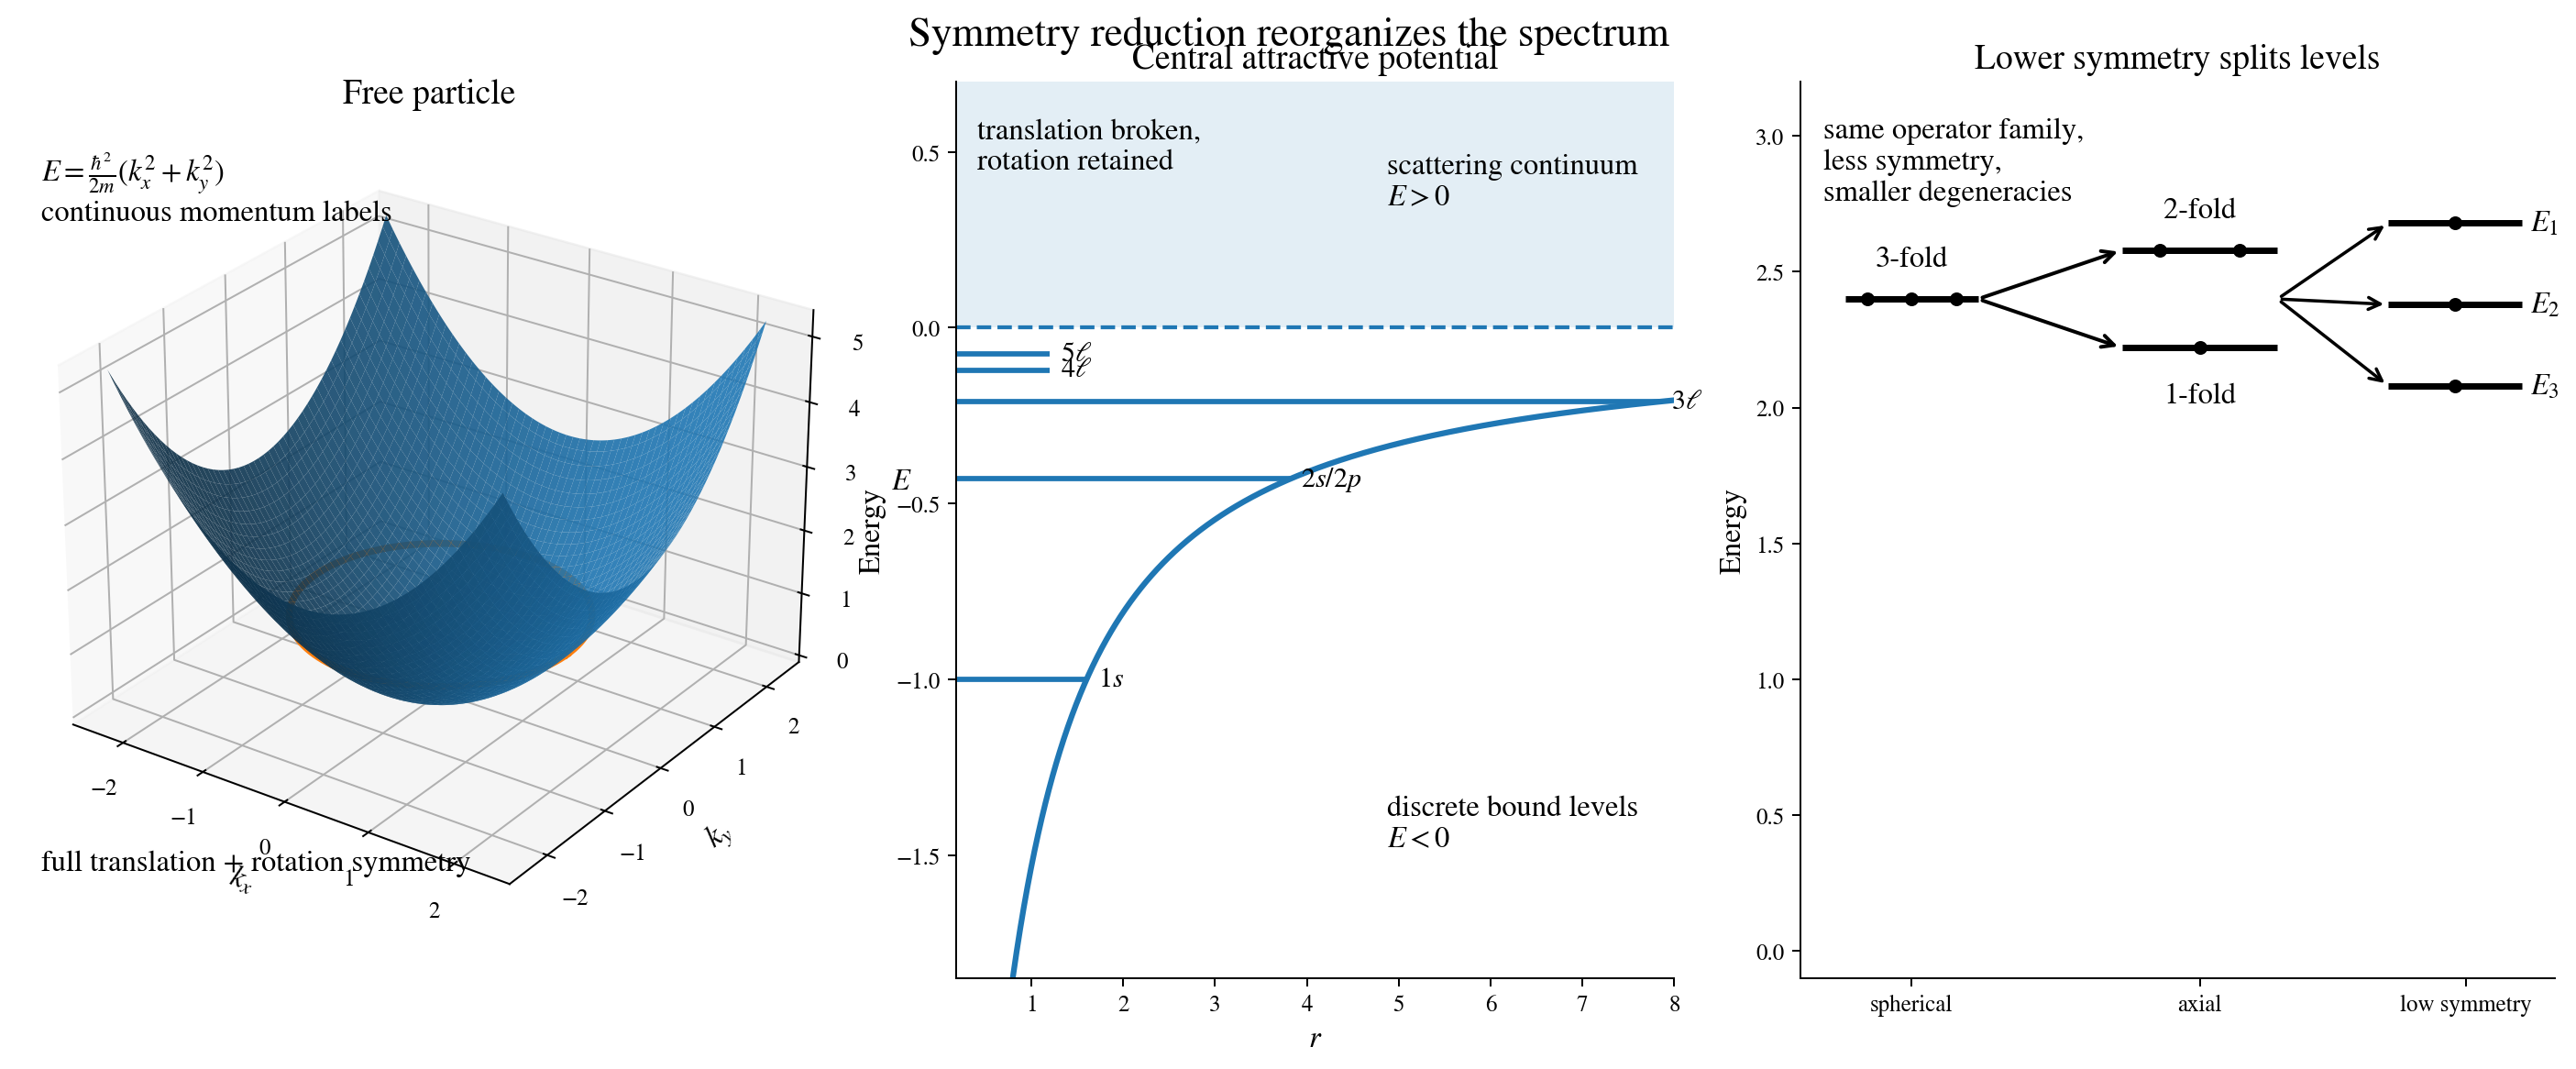

In [5]:
kmax = 2.3
ngrid = 220
KX, KY = make_k_mesh(kmax, ngrid)
E = 0.5 * (KX**2 + KY**2)

# Highlight one equal-energy contour
E0 = 1.15
kr = onp.sqrt(2 * E0)
theta = _2π * onp.linspace(0, 1, 400)
xring = kr * onp.cos(theta)
yring = kr * onp.sin(theta)
zring = onp.full_like(theta, E0 + 0.02)

# ---- central attractive potential
r_min = 0.18
r_max = 8.0
r = onp.linspace(r_min, r_max, 1400)
V = -1.65 / onp.sqrt(r ** 2 + 0.16)


 # Bound-state energies (schematic)
E_bound = onp.array([-1.00, -0.43, -0.21, -0.12, -0.075])
Elabels = [r"$1s$", r"$2s/2p$", r"$3\ell$", r"$4\ell$", r"$5\ell$"]


# Reference degenerate level
Edeg = 2.4
Eax1 = 2.58
Eax2 = 2.22
Elow = [2.68, 2.38, 2.08]



def make_symmetry_breaking_spectrum_figure():
  fig = plt.figure(figsize=(15.5, 6.2), constrained_layout=True)
  gs = GridSpec(1, 3, figure=fig, width_ratios=[1.15, 1.0, 1.05])

  # ============================================================
  # Panel 1: free particle
  # ============================================================
  ax1 = fig.add_subplot(gs[0, 0], projection="3d")
  ax1.plot_surface(KX, KY, E, rstride=4, cstride=4, linewidth=0, antialiased=True, alpha=0.9)
  ax1.plot(xring, yring, zring, lw=3)
  ax1.set(title="Free particle", xlabel=r"$k_x$", ylabel=r"$k_y$", zlabel=r"$E$")
  ax1.text2D(0.03, 0.96, r"$E=\frac{\hbar^2}{2m}(k_x^2+k_y^2)$" "\n" "continuous momentum labels", transform=ax1.transAxes, va="top")
  ax1.text2D(0.03, 0.08, "full translation + rotation symmetry", transform=ax1.transAxes, va="bottom")
  ax1.view_init(elev=27, azim=-55)

  # ============================================================
  # Panel 2: central attractive potential
  # ============================================================
  ax2 = fig.add_subplot(gs[0, 1])
  ax2.plot(r, V, lw=2.5)

  for Eb, lab in zip(E_bound, Elabels):
    idx = onp.argmax(V > Eb)
    x_right = r[idx] if idx > 0 else 1.2
    ax2.hlines(Eb, 0.18, x_right, lw=2.3)
    ax2.text(x_right + 0.12, Eb, lab, va="center", fontsize=12)

  # Continuum threshold
  ax2.axhline(0.0, lw=1.7, ls="--")
  ax2.axhspan(0.0, 0.7, alpha=0.12)

  ax2.text(0.60, 0.92, "scattering continuum\n$E>0$", transform=ax2.transAxes, ha="left", va="top")
  ax2.text(0.60, 0.14, "discrete bound levels\n$E<0$", transform=ax2.transAxes, ha="left", va="bottom")
  ax2.text(0.03, 0.96, "translation broken,\nrotation retained", transform=ax2.transAxes, va="top")

  ax2.set(title="Central attractive potential", xlabel=r"$r$", ylabel="Energy", xlim=(0.18, 8.0), ylim=(-1.85, 0.70))


  for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

  # ============================================================
  # Panel 3: explicit degeneracy splitting under symmetry lowering
  # ============================================================
  ax3 = fig.add_subplot(gs[0, 2])

  ax3.set(title="Lower symmetry splits levels", xlim=(-0.2, 3.2), ylim=(-0.1, 3.2), 
          xticks=[0.3, 1.6, 2.8], xticklabels=["spherical", "axial", "low symmetry"], ylabel="Energy")

  # Spherical: 3-fold degenerate
  ax3.hlines(Edeg, 0.0, 0.6, lw=2.8, colors="k")
  for x in [0.10, 0.30, 0.50]:
    ax3.plot(x, Edeg, marker="o", ms=5, c="k")
  ax3.text(0.30, Edeg + 0.12, "3-fold", ha="center")

  from matplotlib.axes import Axes
  levels = lambda ax, E: Axes.hlines(ax, E, 1.25, 1.95, lw=2.8, colors="k")
  # Axial: doublet + singlet
  levels(ax3, Eax1)
  levels(ax3, Eax2)

  for x in [1.42, 1.78]:
    ax3.plot(x, Eax1, marker="o", ms=5, c="k")
  ax3.plot(1.60, Eax2, marker="o", ms=5, c="k")
  ax3.text(1.60, Eax1 + 0.12, "2-fold", ha="center")
  ax3.text(1.60, Eax2 - 0.20, "1-fold", ha="center")

  # Low symmetry: all split
  for i, E_i in enumerate(Elow):
    ax3.hlines(E_i, 2.45, 3.05, lw=2.8, colors="k")
    ax3.plot(2.75, E_i, marker="o", ms=5, c="k")
    ax3.text(3.09, E_i, rf"$E_{i+1}$", va="center")

  # Arrows showing symmetry reduction
  ax3.annotate("", xy=(1.25, Eax1), xytext=(0.60, Edeg),
    arrowprops=dict(arrowstyle="->", lw=1.6))
  ax3.annotate("", xy=(1.25, Eax2), xytext=(0.60, Edeg),
    arrowprops=dict(arrowstyle="->", lw=1.6))

  for E_i in Elow:
    ax3.annotate("", xy=(2.45, E_i), xytext=(1.95, 0.5 * (Eax1 + Eax2)),
      arrowprops=dict(arrowstyle="->", lw=1.4))

  ax3.text(0.03, 0.96,
    "same operator family,\nless symmetry,\nsmaller degeneracies",
    transform=ax3.transAxes, va="top")

  for spine in ["top", "right"]:
    ax3.spines[spine].set_visible(False)

  fig.suptitle("Symmetry reduction reorganizes the spectrum", y=1.02)
  return fig


if __name__ == "__main__":
  fig = make_symmetry_breaking_spectrum_figure()
  # savefig(fig, "symmetry_breaking_reorganizes_spectrum.png", bbox_inches="tight")
  plt.show()

In [7]:

# ---------------------------
# Geometry
# ---------------------------
k = onp.array([1.2, 0.8, 1.5])
k_l2 = onp.linalg.norm(k)

axis = onp.array([0.0, 0.0, 1.0])
theta = onp.deg2rad(55.0)

R = sym.rotation3d(theta=theta, axis=axis)
k_rot = R.apply(k)

# Sphere |k| = const
u = onp.linspace(0.0, 2.0 * onp.pi, 180)
v = onp.linspace(0.0, onp.pi, 90)

x = k_l2 * onp.outer(onp.cos(u), onp.sin(v))
y = k_l2 * onp.outer(onp.sin(u), onp.sin(v))
z = k_l2 * onp.outer(onp.ones_like(u), onp.cos(v))


def plot_fermi_surface(split=0.10, kz_dependent=True):
  fig = plt.figure(figsize=(7.2, 7.2), dpi=180)
  ax = fig.add_subplot(111, projection="3d")
  ax.set_proj_type("ortho")

  # Transparent background
  fig.patch.set_alpha(0.0)
  ax.set_facecolor((1, 1, 1, 0))

  kz = onp.linspace(-k_l2, k_l2, 180)
  phi = onp.linspace(0.0, 2.0 * onp.pi, 220)
  KZ, PHI = onp.meshgrid(kz, phi, indexing="ij")

  def delta_k(kz):
    if kz_dependent:
      # toy kz-dependent Zeeman splitting
      return split * k_l2 * onp.tanh(kz / (0.45 * k_l2))
    # uniform Zeeman splitting
    return split * k_l2 * onp.ones_like(kz)


  # Subtle sphere
  # ax.plot_surface(
  #   x, y, z,
  #   rstride=3,
  #   cstride=3,
  #   color="#d9d9d9",
  #   alpha=0.12,
  #   edgecolor="none",
  #   shade=False
  # )
  for sigma, color in [(+1, "#1f77b4"), (-1, "#d62728")]:
    kF_sigma = k_l2 + sigma * delta_k(KZ)
    rho2 = onp.clip(kF_sigma**2 - KZ**2, 0.0, None)
    RHO = onp.sqrt(rho2)

    X = RHO * onp.cos(PHI)
    Y = RHO * onp.sin(PHI)

    ax.plot_surface(
      X, Y, KZ,
      rstride=3,
      cstride=3,
      color=color,
      alpha=0.08,
      edgecolor="none",
      shade=False,
    )

  # ax.quiver(0, 0, -k_l2, 0, 0, 2* k_l2, 
  #           arrow_length_ratio=0.08, linewidth=2.2, color="k")

  # Optional faint great circle in the z=0 plane
  t = onp.linspace(0.0, 2.0 * onp.pi, 400)
  ax.plot(k_l2 * onp.cos(t), k_l2 * onp.sin(t), 0.0 * t,
          linewidth=1.0, alpha=0.25, color="k")

  # Vectors
  ax.quiver(0, 0, 0, k[0], k[1], k[2], 
            arrow_length_ratio=0.08, linewidth=2.2, color="k")

  ax.quiver(0, 0, 0, k_rot[0], k_rot[1], k_rot[2], arrow_length_ratio=0.08, linewidth=2.2, color="#666666")

  # Endpoints
  ax.scatter([k[0], k_rot[0]], [k[1], k_rot[1]], [k[2], k_rot[2]],
             s=26, color=["k", "#666666"], depthshade=False)

  # Labels
  # label offset
  lbl_off = 0.08 * k_l2
  k_lbl = k + lbl_off
  k_rot_lbl = k_rot + lbl_off
  ax.text(k_lbl[0], k_lbl[1], k_lbl[2], r"$\mathbf{k}$", fontsize=16)
  ax.text(k_rot_lbl[0], k_rot_lbl[1], k_rot_lbl[2], r"$R\mathbf{k}$", fontsize=16)

  # Clean framing
  lim = 1.25 * k_l2
  ax.set_box_aspect((1, 1, 1))
  # Remove all axis furniture
  ax.set(xlim=(-lim, lim), ylim=(-lim, lim), zlim=(-lim, lim), xticks=[], yticks=[], zticks=[])
  ax.grid(False)
  ax.set_axis_off()

  # View angle
  ax.view_init(elev=22, azim=36)

  # Figure-level annotation instead of axis title
  lbl = r"Zeeman-split Fermi surfaces"
  # lbl = r"$E(\mathbf{k}) = E(R\mathbf{k})$"
  fig.text(0.5, 0.93, lbl, ha="center", va="center", fontsize=18)
  plt.tight_layout(pad=0.2)
  return fig

  


fig = plot_fermi_surface(split=0.0)
savefig(fig, "fermi_surface_isotropic.png")

PosixPath('media/figures/fermi_surface_isotropic.png')

In [ ]:
def coulomb_like(r, depth=1.0, soft=0.18):
  return -depth / (r + soft)

def scattering_mode(x, k, amp=0.11):
  return amp * onp.sin(k * x)

def bound_mode(x, n, amp=0.16, decay=2.2):
  # qualitative only: oscillatory near the origin, decaying at large r
  return amp * (x ** 0.7) * onp.exp(-decay * x) * onp.sin((n + 1) * onp.pi * x)


# -------------------------
# Left panel: potential V(r)
# -------------------------
r = onp.linspace(0.03, 4.2, 600)
V = coulomb_like(r, depth=0.95, soft=0.16)

# sample bound energies
bound_E = onp.array([-0.72, -0.34, -0.18, -0.09])


# -------------------------
# Upper-right: E > 0 continuum
# -------------------------
x = onp.linspace(0.0, 1.0, 700)
ys = [0.78, 0.52, 0.26]
ks = [7.0, 10.5, 14.0]

# -------------------------
# Lower-right: E < 0 bound states
# -------------------------
bound_y = [0.78, 0.54, 0.30]
nodes = [0, 1, 2]
decays = [3.0, 2.3, 1.75]

def plot():

  fig = plt.figure(figsize=(10.8, 4.4), dpi=220, constrained_layout=True)
  gs = fig.add_gridspec(2, 2, width_ratios=[1.05, 1.35], height_ratios=[1, 1])

  axV = fig.add_subplot(gs[:, 0])
  # upper-right: E > 0 continuum
  ax_ur = fig.add_subplot(gs[0, 1])
  # lower-right: E < 0 bound states
  ax_lr = fig.add_subplot(gs[1, 1])

  # -------------------------
  # Left panel: potential V(r)
  # -------------------------


  axV.plot(r, V, lw=2.6)
  axV.axhline(0.0, ls='--', lw=1.4)

  for E in bound_E:
    axV.hlines(E, xmin=0.10, xmax=3.55, lw=2.0)

  axV.text(3.62, 0.02, r'$E=0$', fontsize=11, va='bottom')
  axV.text(2.15, -0.83, r'$V(r)$', fontsize=12)

  axV.set(xlabel=r'$r$', ylabel='energy', xlim=(0.0, 4.2), ylim=(-1.05, 0.26),
          title='Central attractive potential')
  axV.spines['top'].set_visible(False)
  axV.spines['right'].set_visible(False)

  

  for y0, k in zip(ys, ks):
    ax_ur.hlines(y0, xmin=0.0, xmax=1.0, lw=0.8, alpha=0.35)
    ax_ur.plot(x, y0 + scattering_mode(x, k), lw=2.0)
    ax_ur.text(1.02, y0, fr'$k \approx {k:.1f}$', va='center', fontsize=10)

  ax_ur.text(0.02, 0.95, r'$E>0$', fontsize=12)
  ax_ur.text(0.26, 0.95, 'continuum of scattering states', fontsize=11)

  ax_ur.set(
    xlim=(0.0, 1.15),
    ylim=(0.05, 1.02),
    xticks=[],
    yticks=[],
    title='No decay at infinity  →  continuous energies'
  )
  for spine in ax_ur.spines.values():
    spine.set_visible(False)

  for y0, n, d in zip(bound_y, nodes, decays):
    ax_lr.hlines(y0, xmin=0.0, xmax=1.0, lw=0.8, alpha=0.35)
    mode = bound_mode(x, n=n, decay=d)
    ax_lr.plot(x, y0 + mode, lw=2.0)
    ax_lr.text(1.02, y0, f'{n} radial node' + ('' if n == 1 else 's'), va='center', fontsize=10)

  ax_lr.text(0.02, 0.95, r'$E<0$', fontsize=12)
  ax_lr.text(0.22, 0.95, 'discrete bound modes', fontsize=11)

  ax_lr.set(
    xlim=(0.0, 1.18),
    ylim=(0.08, 1.02),
    xticks=[],
    yticks=[],
    title='Decay at infinity  →  only special modes survive'
  )
  for spine in ax_lr.spines.values():
    spine.set_visible(False)

  fig.suptitle('Hydrogen: continuum above threshold, quantized bound states below', fontsize=14)

  return fig

fig = plot()
# fig.savefig('hydrogen_bound_vs_scattering.svg', transparent=True, bbox_inches='tight')
# fig.savefig('hydrogen_bound_vs_scattering.png', transparent=False, bbox_inches='tight')